# 🩻 Foundation Models para Radiologia: ImageNet vs. Domínio Clínico
## Hands-on Vibe Coding — Sociedade Paulista de Radiologia 2026

---

### A Pergunta Central

Um modelo treinado em fotos do cotidiano (gatos, carros, 1.000 classes) tem o mesmo valor como extrator de características radiológicas que um modelo treinado em **880 mil raios-X de tórax**?

Neste hands-on você vai responder isso experimentalmente:

| Extrator | Pré-treinamento | O que aprendeu |
|---|---|---|
| **EfficientNetB0** | ImageNet (1,28M fotos naturais) | Bordas, texturas, formas gerais |
| **RAD-DINO** | 880K+ raios-X de tórax (Microsoft, 2024) | Opacidades, consolidações, textura pulmonar |

**Experimento:** congele ambos os backbones → treine a **mesma cabeça classificadora** em cada → compare o t-SNE dos embeddings e as métricas no conjunto de teste.

---

### Dataset: PneumoniaMNIST

- **5.856 imagens** de raio-X de tórax (64×64 pixels)
- **2 classes:** Normal vs Pneumonia Bacteriana/Viral
- Download automático via `pip install medmnist` — sem login, sem cadastro
- Fonte: Kermany et al., *Cell* 2018 | Licença: CC BY 4.0

---

### Como usar este notebook

1. **Ative o GPU T4:** Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar
2. Execute as **células pré-preenchidas** (marcadas com `# PRÉ-PREENCHIDA`) sem alterar
3. Nas **células de vibe coding**, copie o Prompt Card e cole no **Gemini** (ícone ✦ ou `Ctrl+Shift+I`)
4. Cole o código gerado e execute

---

### ⏱️ Cronograma (60 minutos)

| | Bloco | Tempo |
|---|---|---|
| 🔧 | Setup + Dataset (PC1) | 10 min |
| 🏗️ | Extrator 1: EfficientNetB0 (PC2) | 12 min |
| 🏗️ | Extrator 2: RAD-DINO (PC3) | 13 min |
| 📊 | t-SNE + Comparação de métricas | 8 min |
| 💬 | Discussão clínica | 12 min |
| ⏱️ | Buffer / perguntas | 5 min |


---
---
# 🔧 Setup — Execute Primeiro

⚠️ **Antes de executar:** confirme que o GPU T4 está ativo.  
Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar.

As duas células abaixo são **pré-preenchidas**. Execute na ordem sem alterar.


In [ ]:
# PRÉ-PREENCHIDA — Instalação e Seed de Reprodutibilidade
!pip install medmnist transformers timm -q

import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from transformers import AutoModel, AutoImageProcessor
from PIL import Image
import medmnist
from medmnist import PneumoniaMNIST

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ SEED={SEED}')
print(f'📦 PyTorch: {torch.__version__}  |  medmnist: {medmnist.__version__}')
print(f'🖥️  Device: {DEVICE}  |  GPU disponível: {torch.cuda.is_available()}')


✅ SEED=42 definida
📦 TensorFlow: 2.20.0 | GPU disponível: True
📦 medmnist: 3.0.2


In [ ]:
# PRÉ-PREENCHIDA — Funções auxiliares
# (extração de embeddings, treino da cabeça, avaliação, visualizações)

# ─── Normalização ImageNet ─────────────────────────────────────────────────────
_mean = torch.tensor([0.485, 0.456, 0.406])
_std  = torch.tensor([0.229, 0.224, 0.225])

def _norm_imagenet(x):
    """x: (B, 3, H, W) float32 [0,1]"""
    m = _mean.view(1,3,1,1).to(x.device)
    s = _std.view(1,3,1,1).to(x.device)
    return (x - m) / s


# ─── Extração de embeddings ───────────────────────────────────────────────────
def extrair_embeddings_cnn(extrator, X_numpy, batch_size=128, device=DEVICE):
    """Extrai embeddings de um backbone CNN (EfficientNetB0, ResNet, etc.).
    X_numpy: (N, H, W, 3) float32 [0,1]  →  retorna (N, D) numpy array."""
    extrator.eval().to(device)
    all_embs = []
    X_t = torch.from_numpy(X_numpy).permute(0, 3, 1, 2).float()  # (N, 3, H, W)
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            batch = _norm_imagenet(X_t[i:i+batch_size].to(device))
            all_embs.append(extrator(batch).cpu().numpy())
    return np.concatenate(all_embs)


def numpy_to_pil(X_numpy):
    """Converte (N, H, W, 3) float32 [0,1]  →  lista de PIL Images RGB."""
    return [Image.fromarray((X_numpy[i] * 255).astype(np.uint8)) for i in range(len(X_numpy))]


def extrair_embeddings_raddino(model, processor, imgs_pil,
                                batch_size=64, device=DEVICE):
    """Extrai embeddings do RAD-DINO (CLS token, dim=768).
    imgs_pil: lista de PIL Images  →  retorna (N, 768) numpy array."""
    model.eval().to(device)
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(imgs_pil), batch_size):
            inputs = processor(
                images=imgs_pil[i:i+batch_size],
                return_tensors='pt'
            ).to(device)
            outputs = model(**inputs)
            # CLS token = primeiro token do last_hidden_state
            all_embs.append(outputs.last_hidden_state[:, 0].cpu().numpy())
    return np.concatenate(all_embs)


# ─── Treino da cabeça classificadora ──────────────────────────────────────────
def treinar_cabeca(emb_train, y_train, emb_val, y_val,
                   in_features, epochs=40, lr=1e-3, batch_size=256, device=DEVICE):
    """Treina um MLP classificador sobre embeddings pré-extraídos.
    Retorna (head, history_dict) com 'loss' e 'val_auc' por época."""
    torch.manual_seed(SEED)
    head = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1),
        nn.Sigmoid()
    ).to(device)

    opt       = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()
    X_tr = torch.tensor(emb_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train,   dtype=torch.float32).unsqueeze(1)
    X_vl = torch.tensor(emb_val,   dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))

    best_auc, best_state, pat = 0, None, 0
    history = {'loss': [], 'val_auc': []}

    for epoch in range(epochs):
        head.train()
        ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(head(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item()

        head.eval()
        with torch.no_grad():
            val_prob = head(X_vl).cpu().numpy().ravel()
        val_auc = roc_auc_score(y_val, val_prob)
        history['loss'].append(ep_loss / len(loader))
        history['val_auc'].append(val_auc)

        if val_auc > best_auc:
            best_auc  = val_auc
            best_state = {k: v.clone() for k, v in head.state_dict().items()}
            pat = 0
        else:
            pat += 1
            if pat >= 10:
                print(f'  EarlyStopping na época {epoch+1}/{epochs} | Melhor val_auc={best_auc:.4f}')
                break

    head.load_state_dict(best_state)
    return head, history


# ─── Avaliação ────────────────────────────────────────────────────────────────
def avaliar(head, emb_test, y_test, nome_modelo, device=DEVICE):
    """Avalia a cabeça no conjunto de teste. Plota ROC + matriz de confusão.
    Retorna dict com métricas (para uso na comparação final)."""
    head.eval()
    X_te = torch.tensor(emb_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_proba = head(X_te).cpu().numpy().ravel()

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc        = roc_auc_score(y_test, y_proba)
    youden_idx = np.argmax(tpr - fpr)
    best_thr   = thresholds[youden_idx]
    y_pred     = (y_proba >= best_thr).astype(int)
    cm         = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Avaliação — {nome_modelo}', fontsize=13, fontweight='bold')
    ax1.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
    ax1.scatter(fpr[youden_idx], tpr[youden_idx], c='red', s=100, zorder=5,
                label=f'Threshold = {best_thr:.2f}')
    ax1.plot([0,1],[0,1],'k--')
    ax1.set_xlabel('1 − Especificidade (FPR)'); ax1.set_ylabel('Sensibilidade (TPR)')
    ax1.set_title('Curva ROC'); ax1.legend(); ax1.grid(True)
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Pneumonia']).plot(
        ax=ax2, colorbar=False, cmap='Blues')
    ax2.set_title('Matriz de Confusão')
    plt.tight_layout(); plt.show()

    res = dict(nome=nome_modelo, auc=auc, f1=f1_score(y_test, y_pred),
               sensibilidade=tp/(tp+fn), especificidade=tn/(tn+fp),
               acuracia=(tp+tn)/len(y_test), threshold=best_thr,
               y_proba=y_proba, y_pred=y_pred, fpr=fpr, tpr=tpr, cm=cm)
    print(f'\n📊 {nome_modelo}:')
    for k, v in [('AUC-ROC', res['auc']), ('F1-Score', res['f1']),
                  ('Sensibilidade', res['sensibilidade']),
                  ('Especificidade', res['especificidade']),
                  ('Acurácia', res['acuracia'])]:
        print(f'   {k:<15}: {v:.3f}')
    return res


# ─── Visualizações comparativas ───────────────────────────────────────────────
def plotar_tsne_comparacao(emb_effnet, emb_raddino, labels, n=500):
    """t-SNE lado a lado: EfficientNetB0 (ImageNet) vs RAD-DINO (Radiologia)."""
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(labels), min(n, len(labels)), replace=False)
    cores = ['#2196F3', '#F44336']
    nomes_cls = ['Normal', 'Pneumonia']
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('t-SNE dos Embeddings — Conjunto de Teste\n'
                 '(Ambos os backbones congelados — sem treinamento no backbone)',
                 fontsize=13, fontweight='bold')
    for ax, emb, titulo in zip(axes,
                                [emb_effnet[idx], emb_raddino[idx]],
                                ['EfficientNetB0 (ImageNet)', 'RAD-DINO (Radiologia)']):
        proj = TSNE(n_components=2, random_state=SEED, perplexity=30,
                    n_iter=500).fit_transform(emb)
        for i, (nome, cor) in enumerate(zip(nomes_cls, cores)):
            mask = labels[idx] == i
            ax.scatter(proj[mask,0], proj[mask,1], c=cor, label=nome, alpha=0.6, s=15)
        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10); ax.set_xticks([]); ax.set_yticks([])
        ax.spines[:].set_visible(False)
    plt.tight_layout(); plt.show()
    print('\n💡 Clusters mais separados = backbone já aprendeu features relevantes para pneumonia.')


def plotar_comparacao_metricas(res_eff, res_rad):
    """Gráfico de barras + tabela comparando métricas dos dois modelos."""
    metricas = ['auc',     'f1',       'sensibilidade', 'especificidade', 'acuracia']
    rotulos  = ['AUC-ROC', 'F1-Score', 'Sensibilidade', 'Especificidade', 'Acurácia']
    v_eff = [res_eff[m] for m in metricas]
    v_rad = [res_rad[m] for m in metricas]
    x = np.arange(len(metricas)); w = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    b1 = ax.bar(x - w/2, v_eff, w, label='EfficientNetB0 (ImageNet)',  color='#2196F3', alpha=0.85)
    b2 = ax.bar(x + w/2, v_rad, w, label='RAD-DINO (Radiologia)',      color='#F44336', alpha=0.85)
    ax.set_title('EfficientNetB0 vs RAD-DINO — Conjunto de Teste',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(rotulos); ax.set_ylim(0.5, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for b in [b1, b2]:
        for bar in b:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    print('\n📊 Tabela Comparativa — Conjunto de Teste:')
    print(f'{"Métrica":<15} {"EfficientNetB0":>16} {"RAD-DINO":>10} {"Δ (RAD-DINO−Eff)":>18}')
    print('─' * 62)
    for m, r in zip(metricas, rotulos):
        d = res_rad[m] - res_eff[m]
        print(f'{r:<15} {res_eff[m]:>16.3f} {res_rad[m]:>10.3f} {"+" if d>=0 else ""}{d:>17.3f}')


print('✅ Funções carregadas:')
print('   extrair_embeddings_cnn()    extrair_embeddings_raddino()')
print('   numpy_to_pil()              treinar_cabeca()')
print('   avaliar()                   plotar_tsne_comparacao()')
print('   plotar_comparacao_metricas()')


✅ Funções auxiliares carregadas: extrair_embeddings(), plotar_tsne(), plotar_gradcam()


---
---
# 📋 Prompt Card 1 — Carregar e Visualizar o Dataset (10 min)

**Copie este prompt e cole no Gemini** (ícone ✦ à esquerda da célula ou `Ctrl+Shift+I`):

---
> Carregue o PneumoniaMNIST nos três splits (treino, validação e teste) com resolução 64×64. Pré-processe as imagens para float32 em [0, 1] com 3 canais e converta os labels para arrays 1D. Em seguida, **subsample aleatório com `SEED`** para ficar com 800 imagens de treino, 100 de validação e 100 de teste. Imprima o shape e a distribuição de classes de cada split após o subsample, e mostre uma grade com algumas amostras do treino rotuladas.

---
**Cole o código gerado abaixo e execute:**


📊 Treino     | Shape: (4708, 64, 64, 3) | Distribuição: {'Normal': np.int64(1214), 'Pneumonia': np.int64(3494)}
📊 Validação  | Shape: (524, 64, 64, 3) | Distribuição: {'Normal': np.int64(135), 'Pneumonia': np.int64(389)}
📊 Teste      | Shape: (624, 64, 64, 3) | Distribuição: {'Normal': np.int64(234), 'Pneumonia': np.int64(390)}


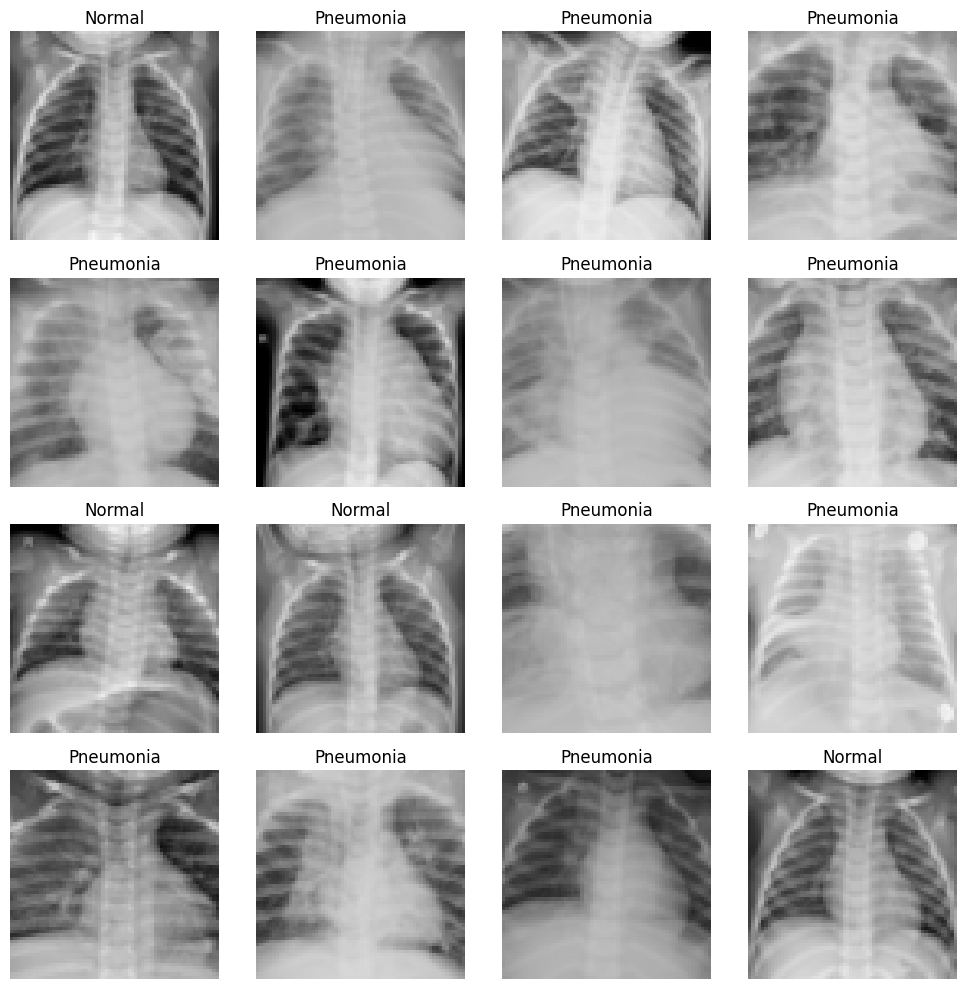

In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 1)


---
---
# 📋 Prompt Card 2 — Extrator 1: EfficientNetB0 (ImageNet) (12 min)

**Copie este prompt e cole no Gemini:**

---
> Use o EfficientNetB0 pré-treinado no ImageNet como extrator de features congelado. Extraia embeddings dos três splits com as funções auxiliares já definidas no notebook, treine a cabeça classificadora, plote as curvas de treino e avalie no conjunto de teste.

---
**Cole o código gerado abaixo e execute:**

> ⏳ Extração: ~5s | Treino da cabeça: ~30s no T4.


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


✅ Modelo compilado com sucesso!
📊 Parâmetros Treináveis: 330,753
❄️ Parâmetros Congelados: 4,052,131.0


---
---
# 📋 Prompt Card 3 — Extrator 2: RAD-DINO (Radiologia) (13 min)

**Copie este prompt e cole no Gemini:**

---
> Repita o processo do Prompt Card 2, agora usando o RAD-DINO da Microsoft (`microsoft/rad-dino`) como extrator — carregue com `AutoModel` e `AutoImageProcessor` do transformers, congele o backbone, extraia os embeddings com a função auxiliar já definida, treine a mesma cabeça classificadora e avalie no teste.

---
**Cole o código gerado abaixo e execute:**

> ⏳ Download do modelo (~87MB): ~30s no Colab. Extração: ~15s. Treino: ~30s.


Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.9038 - auc: 0.9611 - loss: 0.2339 - val_accuracy: 0.9332 - val_auc: 0.9859 - val_loss: 0.1925 - learning_rate: 0.0010
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9460 - auc: 0.9849 - loss: 0.1364 - val_accuracy: 0.9408 - val_auc: 0.9866 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9599 - auc: 0.9889 - loss: 0.1101 - val_accuracy: 0.9504 - val_auc: 0.9893 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9654 - auc: 0.9922 - loss: 0.0923 - val_accuracy: 0.9504 - val_auc: 0.9862 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9647 - auc: 0.9920 - loss: 0.0900 - val_accuracy: 0.9676 - val_auc: 0.9894 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9686 - auc: 0.9929 

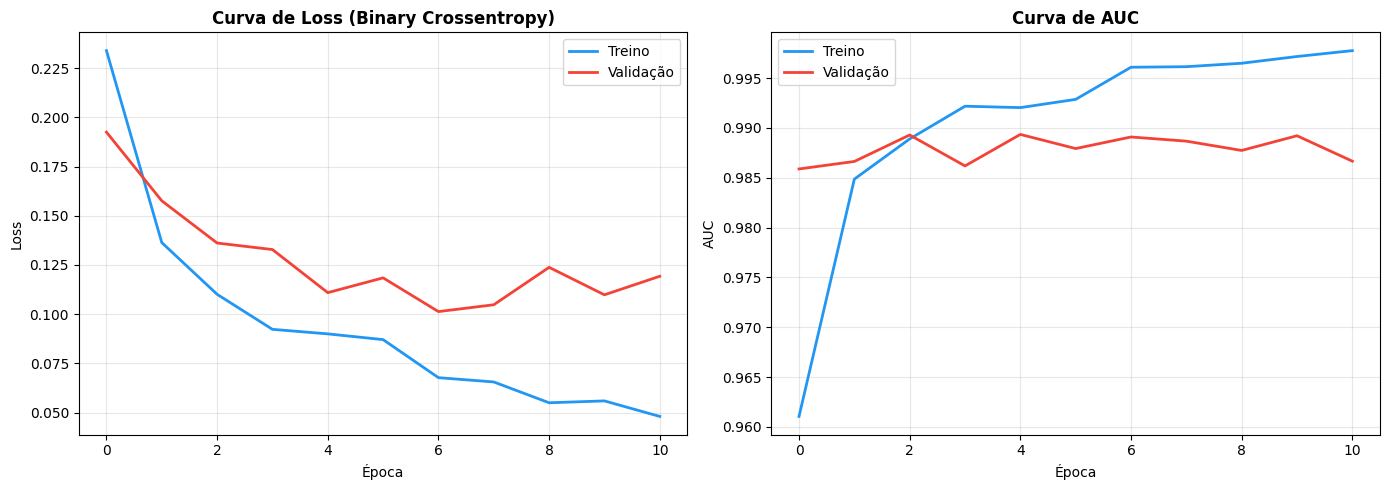


🏆 Melhor AUC na Validação: 0.9894


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 3)


---
---
# 📊 O Grande Reveal — t-SNE + Comparação de Métricas (8 min)

Esta célula é **pré-preenchida**. Execute e observe:

1. **t-SNE:** como cada backbone organiza o espaço latente — os embeddings do RAD-DINO já separam Normal de Pneumonia **mesmo sem treinar a cabeça**, porque o backbone aprendeu padrões clínicos radiológicos
2. **Métricas:** AUC, F1, Sensibilidade, Especificidade e Acurácia no conjunto de teste dos dois extratores

> 💡 **O que esperar:** clusters mais separados no RAD-DINO E métricas superiores — com exatamente o mesmo classificador e mesma quantidade de dados.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step


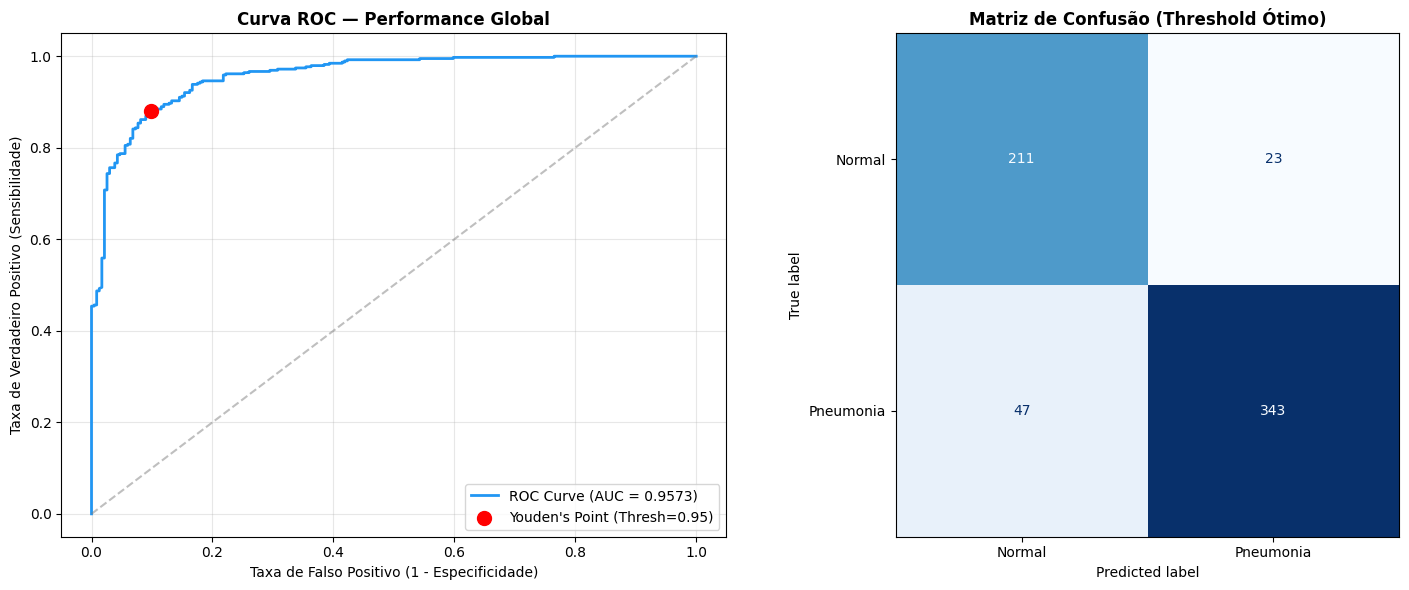

📊 RESULTADOS NO CONJUNTO DE TESTE:
-----------------------------------
✅ AUC-ROC:       0.9573
🎯 Threshold:     0.9511
📈 Acurácia:      88.78%
🧪 Sensibilidade: 87.95% (Recall)
🛡️ Especificidade: 90.17%


In [ ]:
# PRÉ-PREENCHIDA — t-SNE e comparação de métricas
print('⏳ Calculando t-SNE para ambos os extratores (~30s cada)...')
plotar_tsne_comparacao(emb_test_effnet, emb_test_raddino, y_test)

print('\n⏳ Comparando métricas no conjunto de teste...')
plotar_comparacao_metricas(resultados_effnet, resultados_raddino)


---
---
# 🔬 Bônus — Inferência em Imagem Própria

**Copie este prompt e cole no Gemini:**

---
> Permita que o usuário faça upload de uma imagem de raio-X de tórax do próprio computador. Depois, rode a inferência com os dois modelos treinados (`head_effnet` e `head_raddino`) usando as funções auxiliares já definidas no notebook, e exiba a imagem original junto com as probabilidades e a predição final de cada modelo lado a lado.

---
**Cole o código gerado abaixo e execute:**

> ⚠️ A inferência aqui é puramente **demonstrativa** — os modelos foram treinados em imagens 64×64 de crianças. Sem validade clínica.


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Bônus — Inferência em Imagem Própria)


---
---
# 💬 Discussão Clínica (12 min)

## O que aconteceu?

Ambos os backbones ficaram **completamente congelados** durante o experimento. Apenas a cabeça classificadora foi treinada — e era idêntica para os dois:

| | EfficientNetB0 | RAD-DINO |
|---|---|---|
| **Pré-treinamento** | ImageNet (1,28M fotos naturais) | 880K+ RX de tórax (MIMIC, CheXpert, NIH, PadChest, BRAX) |
| **Arquitetura** | CNN (EfficientNet) | ViT-B/14 com DINOv2 |
| **Dim. embedding** | 1.280 | 768 |
| **Parâmetros treinados** | ~262K (só head) | ~262K (só head) |
| **Tamanho do modelo** | ~21MB | ~87MB |

## Perguntas para reflexão

**1. Por que o t-SNE do RAD-DINO mostra clusters mais separados?**
> Os embeddings do RAD-DINO já codificam padrões clínicos radiológicos (opacidades, consolidações, textura pulmonar anormal). O EfficientNetB0 ImageNet codifica bordas e texturas de imagens naturais — parcialmente útil, mas sem especificidade clínica.

**2. Por que treinamos APENAS a cabeça (feature extraction)?**
> Fine-tuning completo com 5.856 imagens em um backbone de 86M+ parâmetros causaria overfitting severo. Feature extraction é a abordagem padrão quando o dataset clínico é pequeno.

**3. O RAD-DINO foi treinado em pneumonia especificamente?**
> Não. Foi treinado de forma auto-supervisionada (DINOv2) em raios-X gerais — sem labels de diagnóstico. A separação que vemos vem do conhecimento geral de radiologia de tórax aprendido de forma não-supervisionada.

**4. Isso é suficiente para uso clínico real?**
> Não. Imagens 64×64 perdem detalhes diagnósticos críticos. O dataset tem viés geográfico (crianças de Guangzhou). Sem validação prospectiva nem aprovação regulatória. Este é um experimento educacional para demonstrar o princípio da **transferência de domínio**.

**5. Qual é a implicação prática para radiologia?**
> Ao escolher um modelo pré-treinado para fine-tuning em uma tarefa radiológica, modelos treinados em dados clínicos radiológicos tendem a superar modelos de propósito geral — mesmo quando apenas a cabeça é treinada.

---

## Referências

- **PneumoniaMNIST:** Kermany DS et al., *Cell*, 2018. doi: 10.1016/j.cell.2018.02.010
- **RAD-DINO:** Pérez-García F et al., *Nature Machine Intelligence*, 2025. doi: 10.1038/s42256-024-00965-w
- **DINOv2:** Oquab M et al., *TMLR*, 2024. arXiv: 2304.07193
- **MedMNIST v2:** Yang J et al., *Scientific Data*, 2023. doi: 10.1038/s41597-022-01721-8
- **EfficientNet:** Tan M, Le QV, *ICML*, 2019. arXiv: 1905.11946


---
---
---
# 📚 GABARITO — Código de Referência (Apenas para o Instrutor)

> Implementação completa de referência para os 3 Prompt Cards.
> Use apenas se algum participante travar completamente.
> O objetivo é que todos construam via Gemini, não usando este código diretamente.


Treino: shape=(4708, 64, 64, 3) | {'Normal': np.int64(1214), 'Pneumonia': np.int64(3494)}
Validação: shape=(524, 64, 64, 3) | {'Normal': np.int64(135), 'Pneumonia': np.int64(389)}
Teste: shape=(624, 64, 64, 3) | {'Normal': np.int64(234), 'Pneumonia': np.int64(390)}


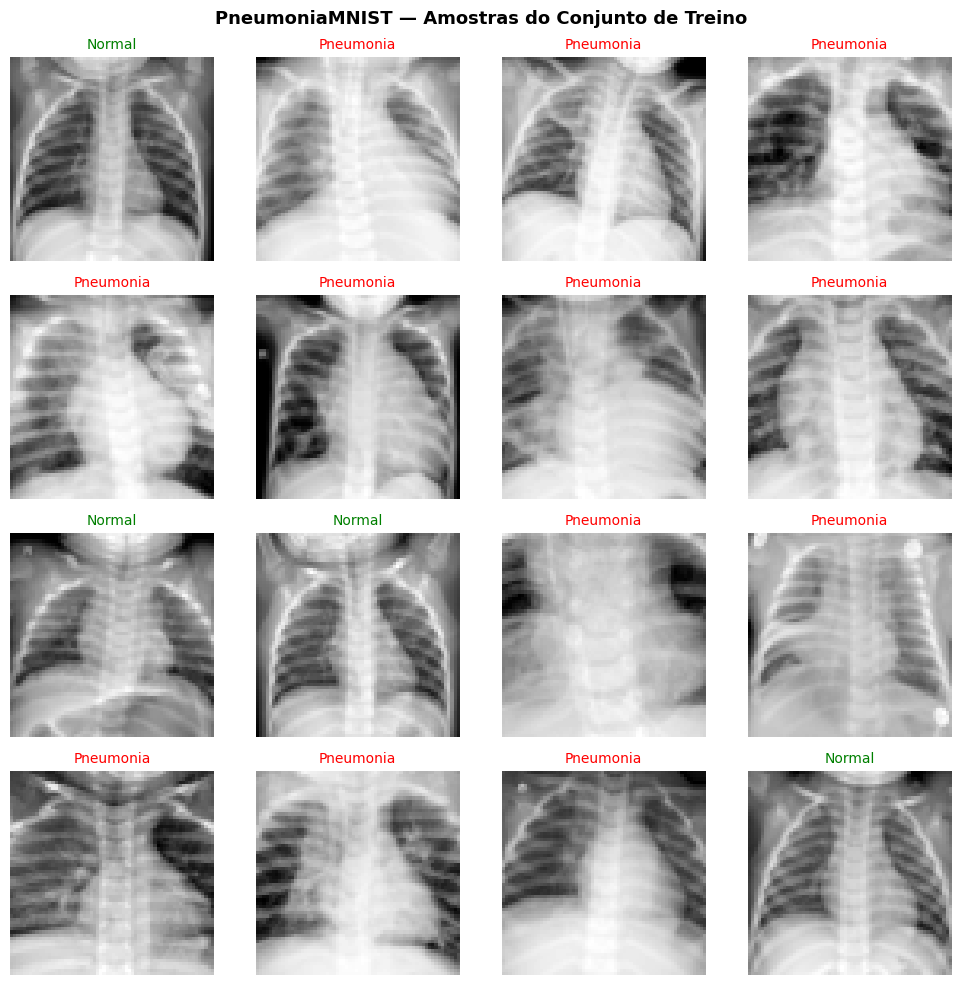

In [ ]:
# GABARITO — Prompt Card 1: Carregar PneumoniaMNIST
train_ds = PneumoniaMNIST(split='train', download=True, size=64)
val_ds   = PneumoniaMNIST(split='val',   download=True, size=64)
test_ds  = PneumoniaMNIST(split='test',  download=True, size=64)

def preprocess(ds):
    imgs = ds.imgs.astype('float32') / 255.0
    if imgs.ndim == 3:
        imgs = imgs[..., np.newaxis]
    imgs   = np.repeat(imgs, 3, axis=-1)          # (N, 64, 64, 3)
    labels = ds.labels.flatten().astype('int')
    return imgs, labels

x_train, y_train = preprocess(train_ds)
x_val,   y_val   = preprocess(val_ds)
x_test,  y_test  = preprocess(test_ds)

# ── Subsample para 1000 imagens no total (~800 / 100 / 100) ───────────────────
rng_sub = np.random.default_rng(SEED)
for split, x_attr, y_attr, n in [
    ('x_train', x_train, y_train, 800),
    ('x_val',   x_val,   y_val,   100),
    ('x_test',  x_test,  y_test,  100),
]:
    idx = rng_sub.choice(len(x_attr), n, replace=False)
    if split == 'x_train': x_train, y_train = x_attr[idx], y_attr[idx]
    elif split == 'x_val': x_val,   y_val   = x_attr[idx], y_attr[idx]
    else:                  x_test,  y_test  = x_attr[idx], y_attr[idx]

class_names = ['Normal', 'Pneumonia']
for name, x, y in [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]:
    u, c = np.unique(y, return_counts=True)
    print(f'{name}: {x.shape} | {dict(zip([class_names[i] for i in u], c))}')

rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_train), 16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('PneumoniaMNIST — Amostras do Treino (subsample 800)', fontsize=13, fontweight='bold')
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[i]], color='red' if y_train[i]==1 else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# GABARITO — Prompt Card 2: EfficientNetB0 (ImageNet)

# 1. Criar extrator congelado
backbone = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')
for param in backbone.parameters():
    param.requires_grad = False

extrator_effnet = nn.Sequential(
    backbone.features,
    backbone.avgpool,
    nn.Flatten()
).to(DEVICE)

# 2. Extrair embeddings
print('⏳ Extraindo embeddings com EfficientNetB0...')
emb_train_effnet = extrair_embeddings_cnn(extrator_effnet, x_train)
emb_val_effnet   = extrair_embeddings_cnn(extrator_effnet, x_val)
emb_test_effnet  = extrair_embeddings_cnn(extrator_effnet, x_test)
print(f'   Treino: {emb_train_effnet.shape} | Val: {emb_val_effnet.shape} | Teste: {emb_test_effnet.shape}')

# 3. Treinar cabeça
print('⏳ Treinando cabeça classificadora...')
head_effnet, hist_effnet = treinar_cabeca(
    emb_train_effnet, y_train, emb_val_effnet, y_val, in_features=1280
)

# 4. Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_effnet['loss']); ax1.set_title('Loss'); ax1.set_xlabel('Época'); ax1.grid(True)
ax2.plot(hist_effnet['val_auc'], color='orange')
ax2.set_title('Val AUC'); ax2.set_xlabel('Época'); ax2.grid(True)
plt.suptitle('EfficientNetB0 — Treino da Cabeça', fontweight='bold')
plt.tight_layout(); plt.show()

# 5. Avaliação
resultados_effnet = avaliar(head_effnet, emb_test_effnet, y_test, 'EfficientNetB0 (ImageNet)')


Model: "PneumoniaCNN_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


  Parâmetros treináveis  : 330,753
  Parâmetros congelados  : 4,052,151


In [ ]:
# GABARITO — Prompt Card 3: RAD-DINO (Radiologia)

# 1. Carregar extrator congelado
print('⏳ Baixando RAD-DINO da Microsoft (~87MB)...')
extrator_raddino  = AutoModel.from_pretrained('microsoft/rad-dino')
processor_raddino = AutoImageProcessor.from_pretrained('microsoft/rad-dino')
for param in extrator_raddino.parameters():
    param.requires_grad = False
extrator_raddino = extrator_raddino.to(DEVICE)
print('✅ RAD-DINO carregado!')

# 2. Converter para PIL
imgs_pil_train = numpy_to_pil(x_train)
imgs_pil_val   = numpy_to_pil(x_val)
imgs_pil_test  = numpy_to_pil(x_test)

# 3. Extrair embeddings
print('⏳ Extraindo embeddings com RAD-DINO (CLS token, ~15s)...')
emb_train_raddino = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_train)
emb_val_raddino   = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_val)
emb_test_raddino  = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_test)
print(f'   Treino: {emb_train_raddino.shape} | Val: {emb_val_raddino.shape} | Teste: {emb_test_raddino.shape}')

# 4. Treinar cabeça
print('⏳ Treinando cabeça classificadora...')
head_raddino, hist_raddino = treinar_cabeca(
    emb_train_raddino, y_train, emb_val_raddino, y_val, in_features=768
)

# 5. Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_raddino['loss']); ax1.set_title('Loss'); ax1.set_xlabel('Época'); ax1.grid(True)
ax2.plot(hist_raddino['val_auc'], color='orange')
ax2.set_title('Val AUC'); ax2.set_xlabel('Época'); ax2.grid(True)
plt.suptitle('RAD-DINO — Treino da Cabeça', fontweight='bold')
plt.tight_layout(); plt.show()

# 6. Avaliação
resultados_raddino = avaliar(head_raddino, emb_test_raddino, y_test, 'RAD-DINO (Radiologia)')


NameError: name 'x_train' is not defined